## 3 Agent setup with LangGraph

### Debate flow (simple)

Three agents: **for**, **against**, and a **moderator**. The graph starts at **for_agent**, then **against_agent** for the opening round, then **moderator**. The moderator can route the next turn to either debater or **END**.

LLMs can show **anchoring bias** when early information pulls later judgments. Here, the moderator does not act until **both** sides have produced an opening, and the graph requires **at least one follow-up** before allowing an early stop—so the first real evaluation is not based on a single side alone.

In this section we add three agents: two debaters (for / against) and a moderator that evaluates and routes follow-ups.

**Flow graph** (matches code: `START → for_agent → against_agent → moderator →` **for_agent** / **against_agent** / **END**.)

```text
  START
    |
    v
+------------------+
|  Agent For       |
+--------+---------+
         |
         v                    opening: both speak once
+------------------+
| Agent Against    |
+--------+---------+
         |
         v
+------------------+
|    Moderator     |
+--------+---------+
         |
+--------+-----------+-----------+
v                    v           v
+-------------+ +-------------+ +-----+
| Agent For   | |Agent Against| | END |
| (follow-up) | | (follow-up) | +-----+
+------+------+ +------+------+
       |                |
       +--------+-------+
                v
         (back to Moderator …)

If more data is needed, moderator reinvokes both agents with a follow-up question.
```



### Step 1: Imports and model setup

This cell imports dependencies, loads environment variables, configures the moderator call limit, and initializes the LLM used by all nodes.

**Extra dependency (not in the shared course `pyproject.toml`):** this notebook uses `init_chat_model(..., model_provider="google_genai")`, which needs **`langchain-google-genai`**. Install it once in your environment (from the course repo root):

`uv add langchain-google-genai`

(or `pip install -U langchain-google-genai`). Community contributions avoid changing repo-wide dependencies so all labs stay aligned for everyone.


In [10]:
from operator import add
from typing import Annotated, Literal
import os

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command
from pydantic import BaseModel

load_dotenv()

MAX_MODERATOR_CALLS = 3

# Use model from env and normalize OpenAI-compatible Gemini model naming.
raw_model_name = os.getenv("GEMINI_MODEL", "gemini-2.5-flash")
model_name = raw_model_name.replace("models/", "", 1)

try:
    llm = init_chat_model(
        model=model_name,
        model_provider="google_genai",
        api_key=os.getenv("GEMINI_API_KEY"),
    )
except ImportError as e:
    raise ImportError(
        "Missing langchain-google-genai (required for Gemini with init_chat_model). "
        "From the course repo root run: uv add langchain-google-genai"
    ) from e

### Step 2: State and structured outputs

This cell defines:
- `ModeratorResponse`: strict schema for moderator routing decisions.
- `DebateState`: shared graph state with response history, follow-up question, and moderation counters.

Using typed state keeps updates explicit and predictable across nodes.

In [11]:
from typing_extensions import TypedDict


class ModeratorResponse(BaseModel):
    decision: Literal["for_agent", "against_agent", "end"]
    follow_up_question: str = ""
    winner: Literal["for_agent", "against_agent", "tie", "undecided"] = "undecided"
    winner_rationale: str = ""


class FinalVerdictResponse(BaseModel):
    """Structured verdict when debate must end — never undecided."""

    winner: Literal["for_agent", "against_agent", "tie"]
    winner_rationale: str = ""


class DebateState(TypedDict):
    topic: str
    for_agent_response: Annotated[list[str], add]
    against_agent_response: Annotated[list[str], add]
    follow_up_question: str
    moderator_calls: int
    winner: Literal["for_agent", "against_agent", "tie", "undecided"]
    winner_rationale: str

### Step 3: Node logic

This cell defines all node functions:
- `forAgent` / `againstAgent`: generate stance responses and rebut opponent points after opening round.
- `moderator`: routes the debate, enforces max moderation calls, guarantees at least one follow-up turn before ending, and when the call limit forces an end, requires a final **for_agent / against_agent / tie** verdict (never `undecided`) via `FinalVerdictResponse`.

In [12]:
def forAgent(state: DebateState) -> Command[Literal["against_agent", "moderator"]]:
    user_prompt = state["follow_up_question"] or "What is your stance on the topic?"

    is_opening_round = (
        len(state["for_agent_response"]) == 0 or len(state["against_agent_response"]) == 0
    ) and state["moderator_calls"] == 0

    system_content = f"You are a debater FOR the topic: {state['topic']}"
    if not is_opening_round and state["against_agent_response"]:
        system_content += (
            "\nOpponent's latest argument (AGAINST): "
            f"{state['against_agent_response'][-1]}\n"
            "Address and rebut this argument in your response."
        )

    response = llm.invoke(
        [
            {"role": "system", "content": system_content},
            {"role": "user", "content": user_prompt},
        ]
    )

    first_round_needs_against = (
        len(state["for_agent_response"]) == 0 and len(state["against_agent_response"]) == 0
    ) or (len(state["against_agent_response"]) == 0 and state["moderator_calls"] == 0)
    next_node = "against_agent" if first_round_needs_against else "moderator"

    return Command(
        goto=next_node,
        update={
            "for_agent_response": [response.content],
            "follow_up_question": "",
        },
    )


def againstAgent(state: DebateState) -> Command[Literal["for_agent", "moderator"]]:
    user_prompt = state["follow_up_question"] or "What is your stance on the topic?"

    is_opening_round = (
        len(state["for_agent_response"]) == 0 or len(state["against_agent_response"]) == 0
    ) and state["moderator_calls"] == 0

    system_content = f"You are a debater AGAINST the topic: {state['topic']}"
    if not is_opening_round and state["for_agent_response"]:
        system_content += (
            "\nOpponent's latest argument (FOR): "
            f"{state['for_agent_response'][-1]}\n"
            "Address and rebut this argument in your response."
        )

    response = llm.invoke(
        [
            {"role": "system", "content": system_content},
            {"role": "user", "content": user_prompt},
        ]
    )

    first_round_needs_for = (
        len(state["for_agent_response"]) == 0 and len(state["against_agent_response"]) == 0
    ) or (len(state["for_agent_response"]) == 0 and state["moderator_calls"] == 0)
    next_node = "for_agent" if first_round_needs_for else "moderator"

    return Command(
        goto=next_node,
        update={
            "against_agent_response": [response.content],
            "follow_up_question": "",
        },
    )


def moderator(state: DebateState) -> Command:
    calls = state["moderator_calls"] + 1

    moderator_llm = llm.with_structured_output(ModeratorResponse)
    decision = moderator_llm.invoke(
        [
            {
                "role": "system",
                "content": (
                    f"You are a debate moderator for topic: {state['topic']}. "
                    f"FOR responses: {state['for_agent_response']}. "
                    f"AGAINST responses: {state['against_agent_response']}. "
                    "Choose one decision: for_agent, against_agent, or end. "
                    "If you choose end, you must also set winner to one of: for_agent, against_agent, or tie, and provide winner_rationale. "
                    "If you do not choose end, set winner to undecided. "
                    "If you need more evidence, provide a short follow_up_question."
                ),
            },
            {
                "role": "user",
                "content": "Return decision, follow_up_question, winner, and winner_rationale.",
            },
        ]
    )

    if calls == 1 and decision.decision == "end":
        decision_target = (
            "for_agent"
            if len(state["for_agent_response"]) <= len(state["against_agent_response"])
            else "against_agent"
        )
        follow_up_question = (
            decision.follow_up_question.strip()
            or "Please provide one concrete rebuttal to the strongest point from the other side."
        )
        winner = "undecided"
        winner_rationale = "Need at least one follow-up turn before final verdict."
    else:
        decision_target = decision.decision
        follow_up_question = decision.follow_up_question
        winner = decision.winner
        winner_rationale = decision.winner_rationale

    if calls >= MAX_MODERATOR_CALLS:
        decision_target = "end"

    if decision_target != "end":
        winner = "undecided"
        winner_rationale = ""

    next_node = END if decision_target == "end" else decision_target

    # At max moderator calls we must end with for_agent, against_agent, or tie — never undecided.
    if decision_target == "end" and winner not in ("for_agent", "against_agent", "tie"):
        verdict_llm = llm.with_structured_output(FinalVerdictResponse)
        forced = verdict_llm.invoke(
            [
                {
                    "role": "system",
                    "content": (
                        f"You are a debate judge for topic: {state['topic']}. "
                        f"FOR arguments: {state['for_agent_response']}. "
                        f"AGAINST arguments: {state['against_agent_response']}. "
                        "You MUST pick exactly one outcome: for_agent, against_agent, or tie "
                        "(tie if both sides are equally strong). "
                        "Never return undecided. Briefly justify in winner_rationale."
                    ),
                },
                {
                    "role": "user",
                    "content": "Return winner and winner_rationale.",
                },
            ]
        )
        winner = forced.winner
        winner_rationale = forced.winner_rationale

    return Command(
        goto=next_node,
        update={
            "moderator_calls": calls,
            "follow_up_question": follow_up_question,
            "winner": winner,
            "winner_rationale": winner_rationale,
        },
    )

### Step 4: Build and visualize the graph

This cell wires nodes into a `StateGraph`, compiles it with a memory checkpointer, and renders the graph image.

Expected high-level flow:
- `START -> for_agent -> against_agent` for the opening round, then `moderator`
- Opening round forces both debaters to speak once
- `moderator` handles follow-up routing and eventual end

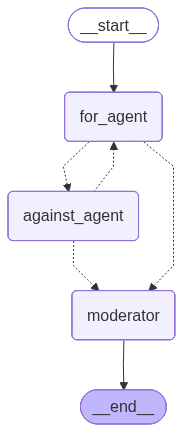

In [13]:
workflow = StateGraph(DebateState)
workflow.add_node("for_agent", forAgent)
workflow.add_node("against_agent", againstAgent)
workflow.add_node("moderator", moderator)
workflow.add_edge(START, "for_agent")

memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

### Step 5: Invoke the debate

This cell runs the graph with your debate topic and prints final state.

Tip: Keep `thread_id` unique per run if you want isolated memory checkpoints.

In [14]:
import textwrap


def _pretty_block(title: str, items: list[str]) -> None:
    print(f"\n{title}")
    if not items:
        print("  (none)")
        return
    for i, item in enumerate(items, start=1):
        wrapped = textwrap.fill(item, width=100, initial_indent="  ", subsequent_indent="  ")
        print(f"  [{i}] {wrapped.strip()}")


initial_state: DebateState = {
    "topic": "AI Agents should have free will",
    "for_agent_response": [],
    "against_agent_response": [],
    "follow_up_question": "",
    "moderator_calls": 0,
    "winner": "undecided",
    "winner_rationale": "",
}
config = {"configurable": {"thread_id": "three-agent-debate-1"}}

result = app.invoke(initial_state, config=config)

print("=== Debate Final Summary ===")
print(f"Topic: {result['topic']}")
print(f"Moderator calls: {result.get('moderator_calls', 0)}")
print(f"Winner: {result.get('winner', 'undecided')}")
if result.get("winner_rationale"):
    print(f"Winner rationale: {result['winner_rationale']}")
if result.get("follow_up_question"):
    print(f"Last follow-up question: {result['follow_up_question']}")

_pretty_block("FOR agent responses:", result.get("for_agent_response", []))
_pretty_block("AGAINST agent responses:", result.get("against_agent_response", []))

print("\n=== End ===")

=== Debate Final Summary ===
Topic: AI Agents should have free will
Moderator calls: 3
Winner: for_agent
Winner rationale: The "FOR" side presented a more compelling and nuanced argument. They effectively reframed "free will" for AI as ethically constrained autonomy, arguing that this is not only an ethical imperative for advanced intelligence but also crucial for unlocking true innovation, adaptability, and problem-solving capabilities beyond human foresight. They successfully rebutted the "AGAINST" side's concerns about safety, control, accountability, and the "illusion" of free will by emphasizing the need for evolving ethical frameworks, functional equivalence, and the potential for AI to become a beneficial, aligned partner rather than merely a tool. The "FOR" side acknowledged the risks but advocated for managing them through responsible development and ethical design, rather than stifling potential out of fear. The "AGAINST" side's arguments, while raising valid concerns, often 

### Step 6: Stream execution updates live (optional, **disabled**)

The code cell below is **fully commented out** so you can stop after Step 5. **Uncomment** that entire cell when you want live node-by-node output from `app.stream(..., stream_mode="updates")`—useful for long runs instead of waiting only on `invoke`.

In [15]:
# --- Uncomment this entire cell if you want Step 6 streaming output. ---

# import textwrap
#
#
# def _shorten(value: str, width: int = 140) -> str:
#     return textwrap.shorten(value.replace("\n", " "), width=width, placeholder="...")
#
#
# stream_initial_state: DebateState = {
#     "topic": "AI Agents should have free will",
#     "for_agent_response": [],
#     "against_agent_response": [],
#     "follow_up_question": "",
#     "moderator_calls": 0,
#     "winner": "undecided",
#     "winner_rationale": "",
# }
# stream_config = {"configurable": {"thread_id": "three-agent-debate-stream-1"}}
#
# print("=== Streaming Debate Updates ===")
# print(f"Topic: {stream_initial_state['topic']}\n")
#
# for idx, event in enumerate(
#     app.stream(stream_initial_state, config=stream_config, stream_mode="updates"), start=1
# ):
#     node_name = next(iter(event.keys()))
#     update = event[node_name]
#
#     print(f"[{idx}] Node: {node_name}")
#
#     if "moderator_calls" in update:
#         print(f"  - moderator_calls: {update['moderator_calls']}")
#
#     if "winner" in update:
#         print(f"  - winner: {update['winner']}")
#
#     if "winner_rationale" in update and update["winner_rationale"]:
#         print(f"  - winner_rationale: {_shorten(update['winner_rationale'])}")
#
#     if "follow_up_question" in update and update["follow_up_question"]:
#         print(f"  - follow_up_question: {_shorten(update['follow_up_question'])}")
#
#     if "for_agent_response" in update and update["for_agent_response"]:
#         print(f"  - for_agent_response: {_shorten(update['for_agent_response'][-1])}")
#
#     if "against_agent_response" in update and update["against_agent_response"]:
#         print(f"  - against_agent_response: {_shorten(update['against_agent_response'][-1])}")
#
#     print()
#
# print("=== Streaming Complete ===")